# Assignment 4: Single-Neuron Network with and without PCA

**Universidad de Monterrey**  
**Curso:** Inteligencia Artificial II  
**Docente:** Dr. Andrés Hernández Gutiérrez  
**Estudiantes:** Jorge Serangelli · Aldo Peña · Jerónimo  
**Fecha:** 05 de marzo de 2026  
**Lugar:** San Pedro Garza García, Nuevo León


## 1. Introducción al Problema Real

### Selección y Descripción del Dataset

Para este trabajo se seleccionó el dataset **Bank Marketing** del UC Irvine Machine Learning Repository (Moro et al., 2014).  
Este dataset proviene de campañas de marketing directo (llamadas telefónicas) realizadas por un banco portugués, donde el objetivo era predecir si un cliente suscribiría un depósito a plazo fijo.

**Fuente:** [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)

**Dominio de aplicación:** Marketing bancario y predicción de comportamiento del cliente. 
Este tipo de modelos es relevante en la industria financiera para optimizar campañas de captación, 
reducir costos operativos y mejorar la experiencia del cliente al contactar únicamente a quienes tienen mayor probabilidad de suscribirse.

**Variable objetivo (`y`):** Indica si el cliente suscribió (`yes`) o no (`no`) un depósito a plazo fijo — problema de clasificación binaria.

**Variables predictoras (16 en total):**

| Categoría | Variable | Descripción |
|---|---|---|
| Demográfica | `age` | Edad del cliente |
| Demográfica | `job` | Tipo de trabajo |
| Demográfica | `marital` | Estado civil |
| Demográfica | `education` | Nivel educativo |
| Financiera | `balance` | Saldo promedio anual (€) |
| Financiera | `default` | Tiene deuda impaga |
| Financiera | `housing` | Tiene préstamo hipotecario |
| Financiera | `loan` | Tiene otro préstamo personal |
| Campaña | `contact` | Tipo de contacto (celular/teléfono) |
| Campaña | `day_of_week` | Día de la semana del último contacto |
| Campaña | `month` | Mes del último contacto |
| Campaña | `duration` | Duración de la última llamada (seg.) |
| Campaña | `campaign` | Número de contactos en esta campaña |
| Campaña | `pdays` | Días desde el último contacto previo |
| Campaña | `previous` | Número de contactos antes de esta campaña |
| Campaña | `poutcome` | Resultado de la campaña anterior |


#### Carga del Dataset

El archivo original usa punto y coma `;` como delimitador, y algunos campos categóricos utilizan `unknown` para representar categorías sin información disponible. 
Al especificar `na_values='unknown'` en la carga, estos valores se convierten en `NaN` para poder tratarlos en la limpieza.


In [41]:
import pandas as pd

columnas = ['age', 'job', 'marital', 'education', 'default', 'balance',
            'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration',
            'campaign', 'pdays', 'previous', 'poutcome', 'y']

df = pd.read_csv(
    'bank-full.csv',
    header=0,
    names=columnas,
    sep=';',
    skipinitialspace=True,
    na_values=['unknown']
)

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas.')
df.head()


Dataset cargado: 45211 registros, 17 columnas.


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


El dataset contiene **45,211 registros** y **17 columnas** (16 variables predictoras + 1 variable objetivo). 
La inspección visual de las primeras filas confirma que la carga fue exitosa: las columnas están correctamente nombradas, 
los tipos de datos son consistentes y los valores tienen coherencia con los esperados para datos bancarios.


#### Tipos de Datos y Dimensiones

Es importante conocer los tipos de datos de cada columna antes de proceder con la limpieza. 
Las variables categóricas (como `job`, `marital`, `education`) requerirán codificación numérica antes de entrenar cualquier modelo, 
ya que los algoritmos de machine learning trabajan exclusivamente con valores numéricos.


In [42]:
print(f'Dimensiones: {df.shape}')
print('\nTipos de datos por columna:')
print(df.dtypes)


Dimensiones: (45211, 17)

Tipos de datos por columna:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object


Se identifican **7 variables numéricas** (`age`, `balance`, `day_of_week`, `duration`, `campaign`, `pdays`, `previous`) 
y **10 variables categóricas** que incluyen la variable objetivo `y`. 
Este balance entre tipos de variables es típico de datasets de marketing y requiere un preprocesamiento.


#### Distribución de la Variable Objetivo

Antes de cualquier preprocesamiento, es fundamental analizar la distribución de la variable objetivo `y`. 
Un desbalance significativo entre clases puede afectar el rendimiento del modelo y requerir estrategias de compensación 
(como pesos de clase o técnicas de muestreo).


In [43]:
print('Distribución de la variable objetivo:')
print(df['y'].value_counts())
print(f"\nPorcentaje positivo (yes): {df['y'].value_counts(normalize=True)['yes']*100:.1f}%")
print(f"Porcentaje negativo (no):  {df['y'].value_counts(normalize=True)['no']*100:.1f}%")


Distribución de la variable objetivo:
y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje positivo (yes): 11.7%
Porcentaje negativo (no):  88.3%


La variable objetivo está **fuertemente desbalanceada**: aproximadamente el **88.3% de los registros corresponden a clientes que no suscribieron** (`no`) 
y solo el **11.7% suscribió** (`yes`). 
Un modelo que siempre predijera `no` lograría ~88% de accuracy sin haber aprendido nada útil, 
por lo que durante el entrenamiento se utilizarán **pesos de clase balanceados** para compensar este problema.


### Limpieza de Datos

Aunque el dataset proviene de un repositorio académico reconocido, nunca es recomendable asumir que los datos están perfectos. 
La limpieza es una etapa crítica que garantiza la calidad de los datos de entrada y, por ende, la confiabilidad de los resultados del modelo.


#### Verificación de Valores Nulos

Al cargar el CSV especificamos `na_values='unknown'`, lo que convierte los valores desconocidos en `NaN`. 
Verificamos cuántos valores faltantes existen por columna para decidir la estrategia de tratamiento adecuada.


In [44]:
print('Valores nulos por columna:')
print(df.isna().sum())
print(f'\nTotal de valores nulos: {df.isna().sum().sum()}')
print(f'\nPorcentaje de nulos por columna:')
nulos_pct = (df.isna().sum() / len(df) * 100).round(2)
print(nulos_pct[nulos_pct > 0])


Valores nulos por columna:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

Total de valores nulos: 52124

Porcentaje de nulos por columna:
job           0.64
education     4.11
contact      28.80
poutcome     81.75
dtype: float64


Se detectan valores nulos en las variables categóricas `job`, `education`, `contact` y `poutcome`, originalmente codificados como `unknown` en el CSV.

Para decidir cómo tratar cada variable, calculamos el porcentaje de nulos que representa sobre el total del dataset. 
Como referencia, cuando una variable supera el 5% de valores faltantes, 
eliminar esas filas implica una pérdida significativa de información y es preferible imputar. 
Por debajo de ese umbral, eliminar las filas es una opción válida sin comprometer el dataset:

- `poutcome` (~81.7% de nulos) → se **imputa con la moda**, ya que eliminar estos registros significaría perder la gran mayoría del dataset
- `contact` (~28.8% de nulos) → se **imputa con la moda** por la misma razón
- `job` (~0.6% de nulos) → se **eliminan las filas**, porcentaje insignificante
- `education` (~4.2% de nulos) → se **eliminan las filas**, porcentaje aceptablemente bajo


In [45]:
# Imputar con la moda las variables con alto porcentaje de nulos
df['poutcome'].fillna(df['poutcome'].mode()[0], inplace=True)
df['contact'].fillna(df['contact'].mode()[0], inplace=True)

print('Nulos después de imputación:')
print(df.isna().sum())

# Eliminar filas con nulos restantes (job y education)
df_clean = df.dropna()
print(f'\nRegistros antes de limpieza:   {df.shape[0]}')
print(f'Registros después de limpieza: {df_clean.shape[0]}')
print(f'Registros eliminados: {df.shape[0] - df_clean.shape[0]} ({(df.shape[0]-df_clean.shape[0])/df.shape[0]*100:.2f}% del total)')
df = df_clean.copy()


Nulos después de imputación:
age               0
job             288
marital           0
education      1857
default           0
balance           0
housing           0
loan              0
contact           0
day_of_week       0
month             0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
dtype: int64

Registros antes de limpieza:   45211
Registros después de limpieza: 43193
Registros eliminados: 2018 (4.46% del total)


C:\Users\jeser\AppData\Local\Temp\ipykernel_65648\2938751726.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['poutcome'].fillna(df['poutcome'].mode()[0], inplace=True)
C:\Users\jeser\AppData\Local\Temp\ipykernel_65648\2938751726.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

#### Verificación de Registros Duplicados

Los registros duplicados pueden provocar **overfitting**, ya que el modelo les otorga mayor peso a patrones repetidos artificialmente. 
Identificamos y eliminamos cualquier fila idéntica en todas sus columnas.


In [46]:
duplicados = df.duplicated(subset=df.columns, keep=False).sum()
print(f'Registros duplicados detectados: {duplicados}')
if duplicados > 0:
    df = df.drop_duplicates()
    print(f'Dimensiones tras eliminar duplicados: {df.shape}')
else:
    print('No se encontraron duplicados. El dataset está limpio.')


Registros duplicados detectados: 0
No se encontraron duplicados. El dataset está limpio.


No se encontraron registros duplicados. El dataset mantiene su integridad y está listo para la etapa de análisis exploratorio.


### Análisis Exploratorio de Datos 

El análisis exploratorio nos permite entender la naturaleza y distribución de los datos antes de modelar. 
Presentamos estadísticas descriptivas, distribuciones de las variables numéricas y análisis de correlación.


#### Estadísticas Descriptivas

Las estadísticas descriptivas proporcionan una visión rápida de la tendencia central y la dispersión de cada variable numérica. 
Esto es esencial para detectar variables con escalas muy diferentes que requieran normalización, así como posibles outliers.


In [47]:
print('Estadísticas descriptivas de variables numéricas:')
df.describe()


Estadísticas descriptivas de variables numéricas:


,age,balance,day_of_week,duration,campaign,pdays,previous
count,43193.000000,43193.000000,43193.000000,43193.000000,43193.000000,43193.000000,43193.000000
mean,40.764082,1354.027342,15.809414,258.323409,2.758178,40.404070,0.584863
std,10.512640,3042.103625,8.305970,258.162006,3.063987,100.420624,2.332672
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,71.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,442.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1412.000000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,58.000000,871.000000,275.000000


Se observan diferencias significativas en las escalas: `balance` tiene valores que alcanzan hasta 102,127 euros, 
mientras que `duration` promedia ~260 segundos y `campaign` generalmente es menor a 3. 
La variable `pdays` presenta el valor -1 para indicar ausencia de contacto previo, lo cual es una codificación especial a tener en cuenta. 
Estas diferencias de escala confirman la **necesidad de estandarizar los datos** antes de entrenar el modelo y aplicar PCA.


#### Distribución de Variables Numéricas

Los histogramas permiten visualizar la forma de la distribución de cada variable. 
Distribuciones muy sesgadas o con múltiples modas pueden indicar subgrupos en los datos o necesidad de transformaciones.


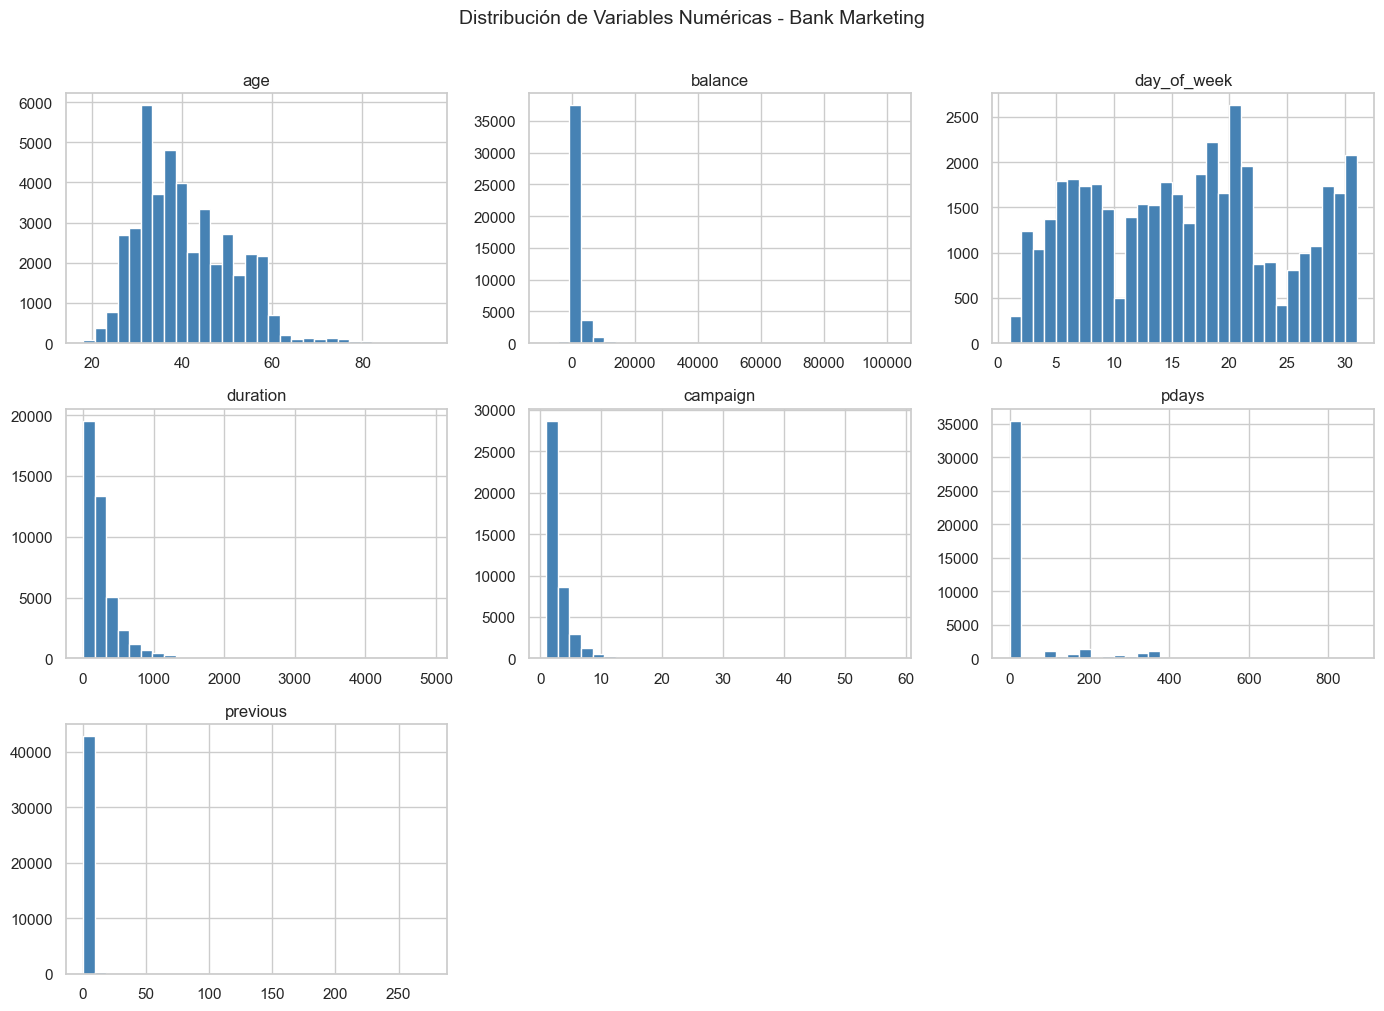

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

num_cols = df.select_dtypes(include=['number']).columns.tolist()

df[num_cols].hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Distribución de Variables Numéricas - Bank Marketing', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Los histogramas revelan que variables como `duration`, `campaign`, `pdays` y `previous` presentan distribuciones **fuertemente sesgadas a la derecha**, 
con la mayoría de los valores concentrados cerca de cero y algunos valores extremos. 
La variable `age` muestra una distribución más cercana a la normal, concentrada entre los 25 y 60 años. 
El `balance` presenta una distribución con cola larga positiva, indicando que la mayoría de los clientes tienen saldos moderados. 
Este comportamiento es típico de datos financieros del mundo real y motiva el uso de estandarización.


#### Análisis de Correlación (Variables Numéricas)

El mapa de calor de correlación identifica relaciones lineales entre las variables numéricas. 
Correlaciones altas entre predictores sugieren **redundancia de información**, lo que es relevante para motivar el uso de PCA más adelante.


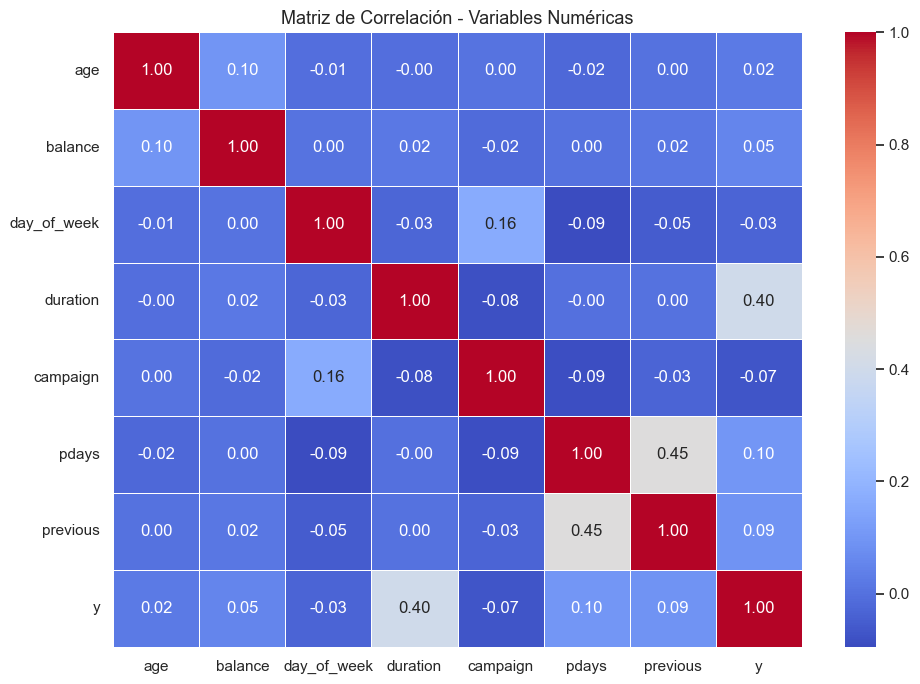

In [49]:
df_corr = df.copy()
df_corr['y'] = df_corr['y'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr[num_cols + ['y']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=13)
plt.tight_layout()
plt.show()


La matriz de correlación revela que las correlaciones entre variables numéricas son en general **bajas**, indicando poca redundancia lineal directa. 
La variable `duration` (duración de la llamada) muestra la correlación más alta con la variable objetivo (~0.40): 
llamadas más largas sugieren mayor interés del cliente. 
La variable `campaign` presenta correlación negativa con `y`, indicando que más intentos de contacto se asocian con menor conversión. 
Esto motiva el análisis de las variables categóricas una vez codificadas, donde es probable encontrar mayor redundancia.


### Preprocesamiento Final: Codificación y Separación de Variables

Antes de entrenar el modelo debemos:
1. **Codificar la variable objetivo** `y` de texto (`yes`/`no`) a numérico (1/0)
2. **Aplicar One-Hot Encoding** a las variables categóricas predictoras

El One-Hot Encoding convierte cada categoría en una columna binaria. Con `drop_first=True` se elimina una de esas columnas porque su información ya está implícita en las demás: si todas las otras columnas son `0`, esa categoría es la que aplica.


In [50]:
# Codificar variable objetivo
df['y'] = df['y'].astype('category').cat.codes  # no=0, yes=1

# Separar features y target
X = df.drop('y', axis=1)
y = df['y']

# One-Hot Encoding para variables categóricas
X = pd.get_dummies(X, drop_first=True)

print(f'Variables después de One-Hot Encoding: {X.shape[1]} features')
print(f'\nNombres de las columnas:')
print(list(X.columns))


Variables después de One-Hot Encoding: 38 features

Nombres de las columnas:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success']


Tras aplicar One-Hot Encoding, el número de variables predictoras aumenta de 16 a **39 features**. 
Esto se debe a que cada variable categórica con $k$ categorías genera $k-1$ columnas binarias nuevas, 
y el `drop_first=True` elimina una por variable. Por ejemplo, `month` con 12 meses genera 11 columnas, 
`job` con 12 tipos de trabajo genera 11, y así sucesivamente. La suma total de todas estas columnas, 
más las 7 variables numéricas originales, da como resultado las 39 features finales. 
Este espacio de mayor dimensionalidad es exactamente el escenario donde PCA resulta especialmente valioso.


#### Matriz de Correlación tras One-Hot Encoding

Visualizamos la correlación entre las 39 features finales para identificar redundancias antes de aplicar el modelo. 
Esta visualización también sirve como motivación para el uso de PCA en la segunda parte del notebook.


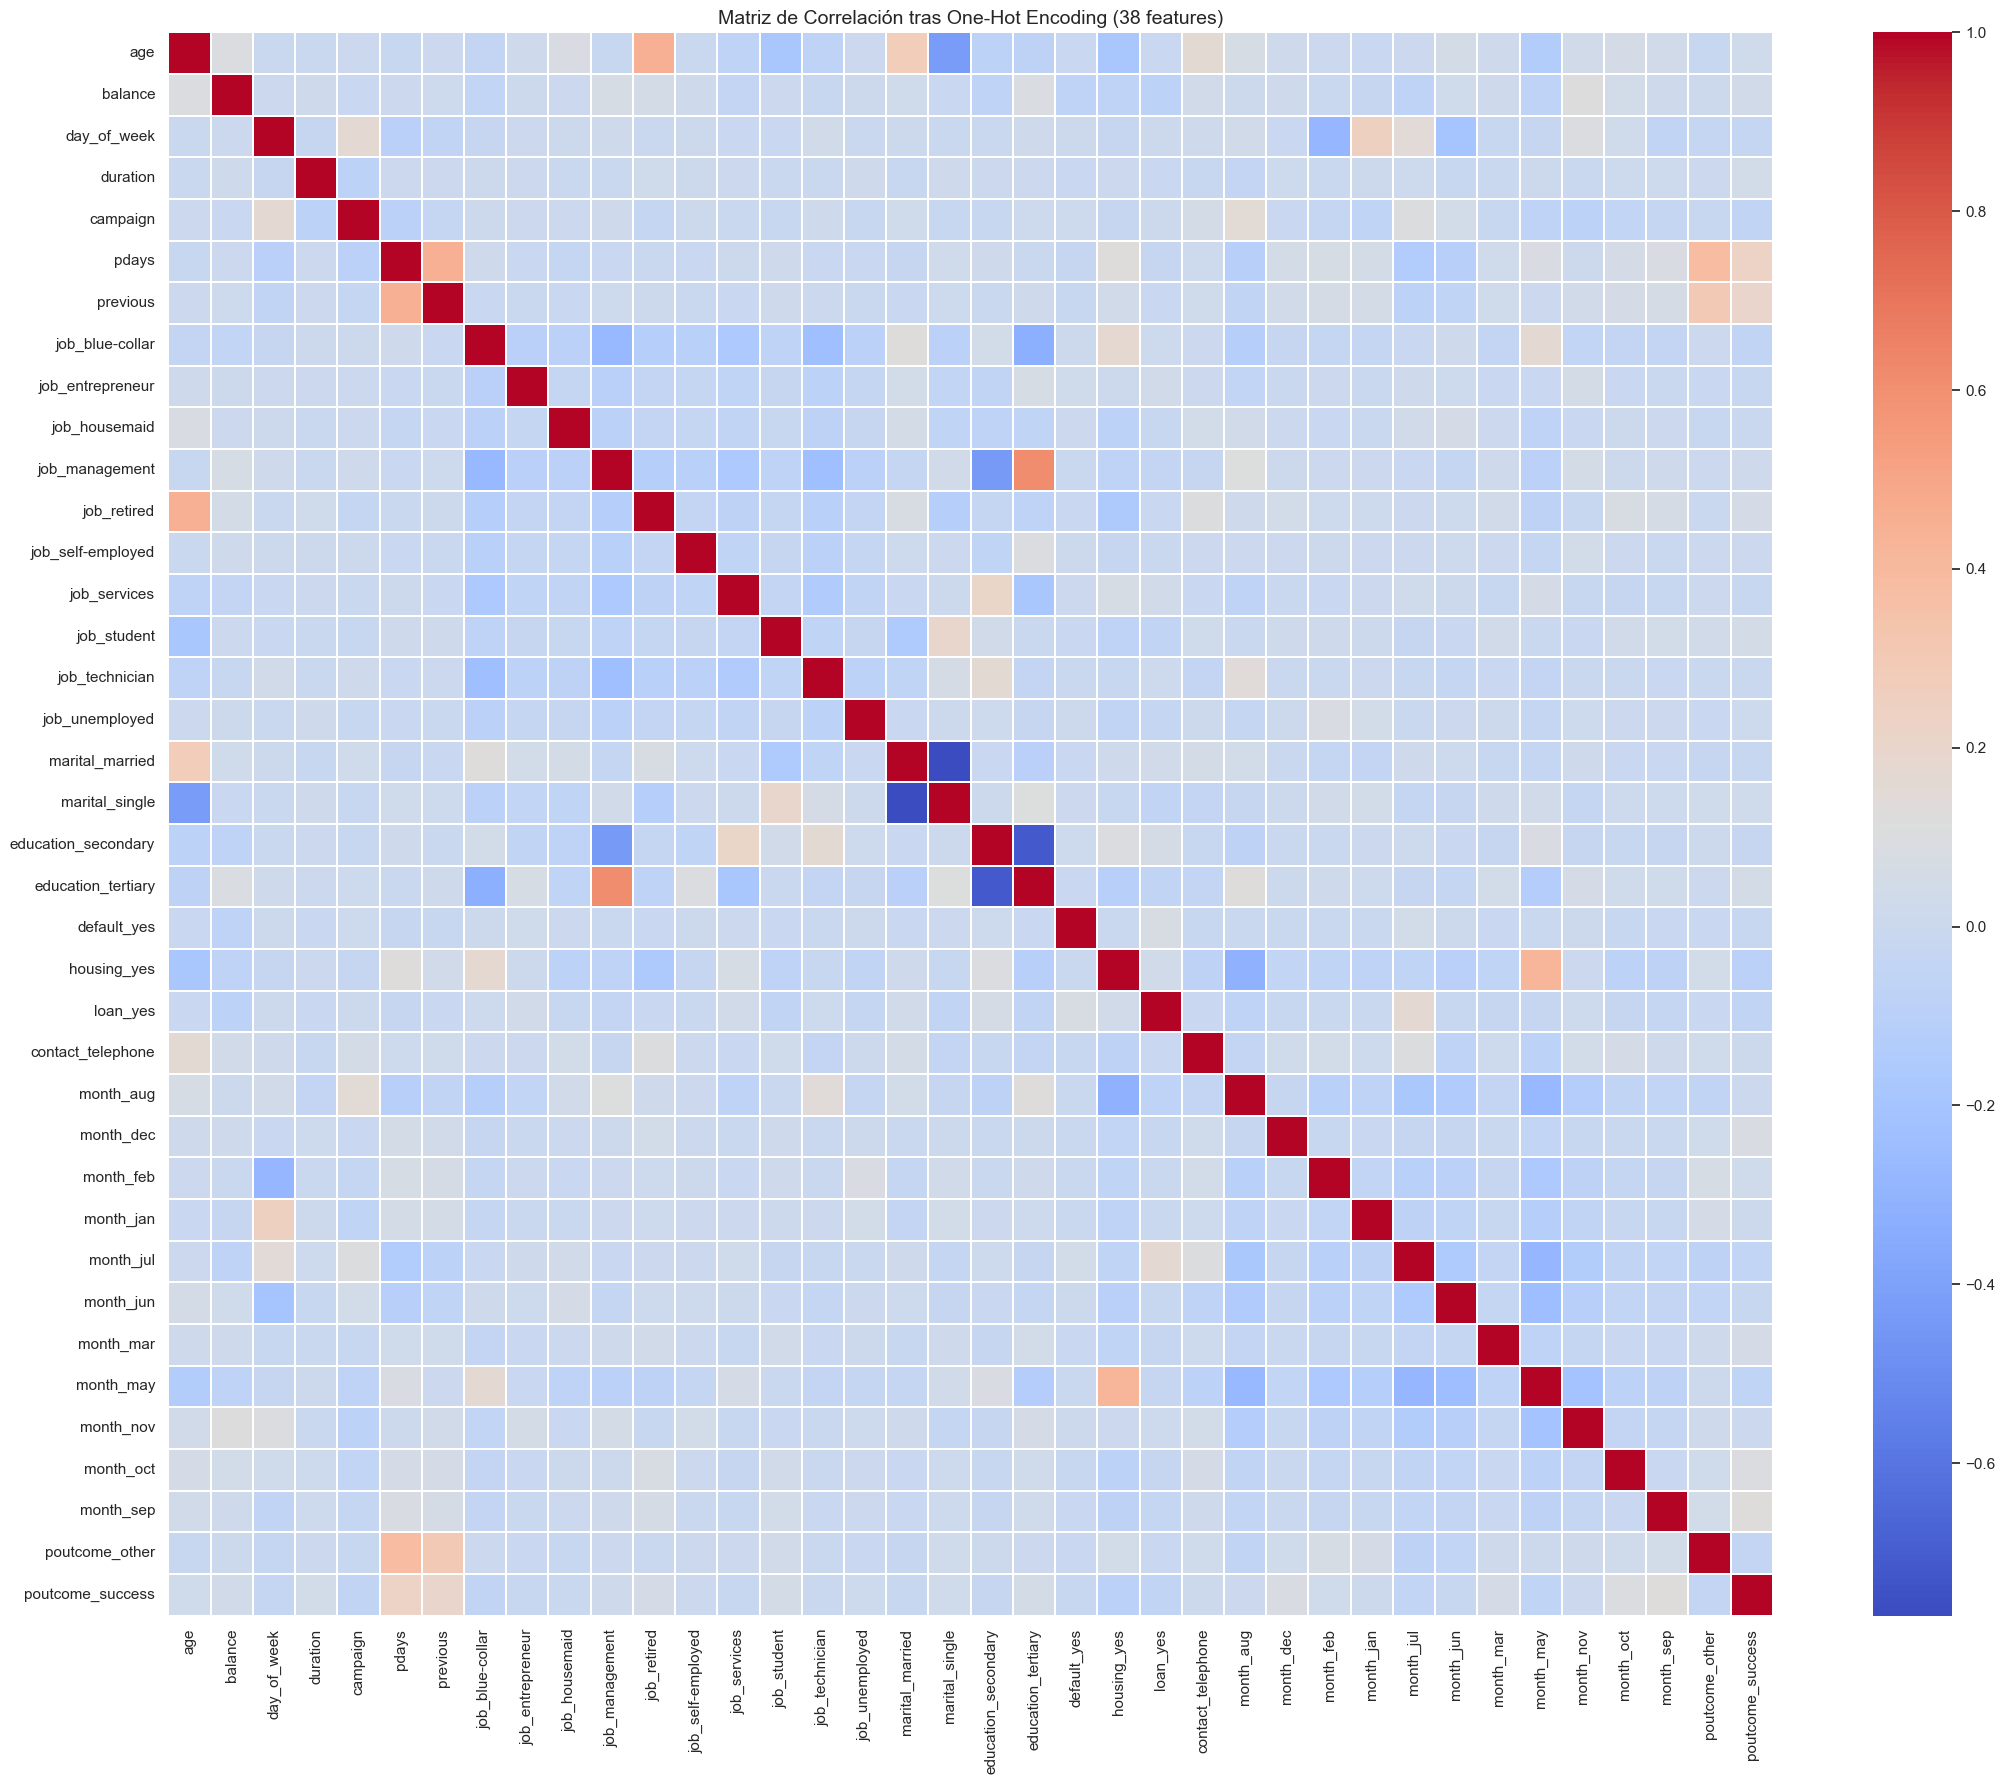

In [51]:
plt.figure(figsize=(22, 18))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False, linewidths=0.2)
plt.title(f'Matriz de Correlación tras One-Hot Encoding ({X.shape[1]} features)', fontsize=14)
plt.tight_layout()
plt.show()


Este mapa de calor ilustra la matriz de correlación de 38 características demográficas y de campaña (tras aplicar One-Hot Encoding), utilizando una escala cromática donde los tonos rojos indican relaciones positivas fuertes y los tonos azules revelan relaciones negativas. Como insight principal, destaca una fuerte correlación positiva entre la edad (age) y la condición de jubilado (job_retired), además de una predecible relación fuertemente negativa entre los estados civiles de soltero y casado.

## 2. Diseño y Entrenamiento del Modelo de Neurona Única

Una neurona única es el componente más fundamental de una red neuronal artificial. 
Recibe las variables de entrada, les asigna un peso a cada una, las suma y aplica la función **sigmoide** al resultado. 
La sigmoide convierte cualquier valor numérico a un rango entre 0 y 1, que interpretamos como la probabilidad de que el cliente suscriba el depósito. 
Si esa probabilidad supera 0.5, el modelo predice `sí`; de lo contrario, predice `no`.


### División Train / Validation / Test

El dataset se divide en tres subconjuntos. Primero, separamos el **20% como conjunto de prueba** (`test_size=0.2`): 
estos datos quedan completamente apartados y el modelo nunca los ve durante el entrenamiento. 
Del **80% restante** que va a entrenamiento, durante el proceso de `model.fit()` se reserva otro **20% como validación** (`validation_split=0.2`), 
lo que equivale al 16% del total original. El **64% restante** es el que el modelo usa para ajustar sus pesos. 
En resumen: 64% entrenamiento, 16% validación y 20% prueba.

La validación sirve para monitorear en tiempo real si el modelo está aprendiendo o sobreajustando, 
mientras que el conjunto de prueba da la evaluación final imparcial.

Se utiliza `stratify=y` para garantizar que la proporción de clases (88%/12%) se preserve en ambas particiones.


In [52]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f'Conjunto de entrenamiento: {x_train.shape[0]} registros ({x_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {x_test.shape[0]} registros ({x_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribución en train - No: {(y_train==0).sum()}, Si: {(y_train==1).sum()}')
print(f'Distribución en test  - No: {(y_test==0).sum()},  Si: {(y_test==1).sum()}')


Conjunto de entrenamiento: 34554 registros (80.0%)
Conjunto de prueba:        8639 registros (20.0%)

Distribución en train - No: 30537, Si: 4017
Distribución en test  - No: 7635,  Si: 1004


La estratificación garantiza que la proporción original (~88%/12%) se mantenga tanto en entrenamiento como en prueba, 
lo cual es fundamental para evitar sesgos en la evaluación del modelo cuando existe desbalance de clases.


### Estandarización de Features

Estandarizamos las variables para que cada una tenga **media cero y desviación estándar uno**. Esto es indispensable porque:
1. El optimizador Adam converge más rápido con datos en la misma escala
2. PCA (sección 6) asume varianzas comparables entre variables

**Nota importante:** el `StandardScaler` se ajusta **solo con los datos de entrenamiento** (`fit_transform`) y se aplica al conjunto de prueba sin re-ajustar (`transform`), 
para evitar **data leakage** — es decir, que información del conjunto de prueba filtre hacia el proceso de entrenamiento.


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)  # Ajustar Y transformar solo en train
x_test_sc  = scaler.transform(x_test)       # Solo transformar en test (sin re-ajustar)

print(f'Media post-estandarización (train):    {x_train_sc.mean():.6f}  (esperado: ~0)')
print(f'Desv. std post-estandarización (train): {x_train_sc.std():.6f}  (esperado: ~1)')


Media post-estandarización (train):    0.000000  (esperado: ~0)
Desv. std post-estandarización (train): 1.000000  (esperado: ~1)


Los valores confirman que la estandarización fue exitosa: la media es prácticamente cero y la desviación estándar es uno, 
garantizando que todas las variables contribuyan equitativamente durante el entrenamiento.


### Arquitectura del Modelo

El modelo de neurona única se implementa como una red secuencial de Keras con una sola capa densa de **1 neurona** y activación **sigmoide**. 
Los hiperparámetros configurados son los siguientes:

Se entrena por un máximo de **100 épocas**, aunque el Early Stopping puede detenerlo antes si deja de mejorar. 
La **tasa de aprendizaje de 0.001** es el valor por defecto de Adam y ofrece un buen balance entre velocidad y estabilidad. 
El **batch size de 32** significa que el modelo actualiza sus pesos después de procesar cada grupo de 32 registros, 
lo que hace el entrenamiento más eficiente que procesar uno por uno o todos a la vez. 
El **validation split de 0.2** separa el 20% del conjunto de entrenamiento para monitorear el modelo en cada época. 
El **patience de 30** le da al modelo hasta 30 épocas adicionales para mejorar antes de detenerse. 
La **Binary Cross-Entropy** es la función de pérdida estándar para clasificación binaria: mide qué tan lejos está la probabilidad predicha del valor real. 
El optimizador **Adam** ajusta los pesos automáticamente de forma eficiente, adaptando la tasa de aprendizaje por cada parámetro.


In [54]:
import tensorflow as tf

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(x_train_sc.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39 (156.00 B)

 Trainable params: 39 (156.00 B)

 Non-trainable params: 0 (0.00 B)

El modelo tiene un parámetro entrenable por cada feature de entrada más un bias. 
Esta simplicidad es intencional: al tener una sola neurona, el modelo es esencialmente una **regresión logística**, 
lo que lo hace completamente interpretable y sirve como baseline sólido.


### Manejo del Desbalance de Clases

El dataset tiene un desbalance importante: por cada cliente que sí suscribió, hay aproximadamente 7.5 que no lo hicieron. 
Si entrenamos sin corrección, el modelo aprende rápidamente que predecir siempre `no` le da una accuracy alta (~88%), 
y nunca se esfuerza en aprender a identificar a los clientes que sí suscriben.

Para corregir esto, le asignamos **pesos diferentes a cada clase** durante el entrenamiento. 
Cuando el modelo comete un error en un cliente que sí suscribió (la clase minoritaria), ese error cuenta mucho más que equivocarse en uno que no suscribió. 
Esto obliga al modelo a prestar más atención a los casos positivos, que son precisamente los que nos interesan detectar en una campaña bancaria.


In [55]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

clases = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))

print(f"Peso clase 0 (no suscribio): {class_weight_dict[0]:.4f}")
print(f"Peso clase 1 (si suscribio): {class_weight_dict[1]:.4f}")
print(f"\nUn error en un cliente que sí suscribio penaliza {class_weight_dict[1]/class_weight_dict[0]:.1f}x mas al modelo")


Peso clase 0 (no suscribio): 0.5658
Peso clase 1 (si suscribio): 4.3010

Un error en un cliente que sí suscribio penaliza 7.6x mas al modelo


Los pesos reflejan el desbalance del dataset: equivocarse en un cliente que sí suscribió penaliza al modelo aproximadamente 7.5 veces más que errar en uno que no suscribió. 
En términos prácticos, esto hace que el modelo sea más cuidadoso antes de descartar a un cliente como `no`, 
priorizando la detección de oportunidades de venta reales.


### Entrenamiento del Modelo

Se utiliza un callback de **Early Stopping** con `patience=30` épocas para detener el entrenamiento cuando la pérdida de validación deja de mejorar. 
El parámetro `restore_best_weights=True` garantiza que al finalizar se utilicen los pesos del epoch con la menor pérdida de validación, 
optimizando el rendimiento en datos no vistos.


In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\nEntrenamiento finalizado en epoca: {len(history.history['loss'])}")


Epoch 1/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.5219 - loss: 0.8060 - val_accuracy: 0.6309 - val_loss: 0.6575
Epoch 2/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.7386 - loss: 0.5094 - val_accuracy: 0.7964 - val_loss: 0.5224
Epoch 3/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8193 - loss: 0.4465 - val_accuracy: 0.8307 - val_loss: 0.4735
Epoch 4/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.8341 - loss: 0.4259 - val_accuracy: 0.8355 - val_loss: 0.4557
Epoch 5/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.8361 - loss: 0.4184 - val_accuracy: 0.8366 - val_loss: 0.4487
Epoch 6/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.8370 - loss: 0.4156 - val_accuracy: 0.8379 - val_loss: 0.4453
Epoch 7/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.8375 - loss: 0.4145 - val_accuracy: 0.8382 - val_loss: 0.4434
Epoch 8/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.8377 - loss: 0

Esta celda muestra el entrenamiento del modelo. En cada época se reporta el accuracy y la pérdida (loss) tanto para entrenamiento como para validación. Se observa que el modelo mejora rápidamente durante las primeras épocas y luego los valores se estabilizan cerca de 0.84 de accuracy.

Aunque el entrenamiento estaba configurado para 100 épocas, el Early Stopping detuvo el proceso en la época 47 cuando el modelo dejó de mejorar. Después, se restauraron los pesos de la mejor época (época 17) para conservar el mejor desempeño alcanzado durante el entrenamiento.

## 3. Análisis de Curvas de Aprendizaje

Las curvas de aprendizaje muestran cómo evolucionan la **accuracy** y la **pérdida (loss)** durante el entrenamiento, 
tanto para el conjunto de entrenamiento como para el de validación. 
Son la herramienta principal para diagnosticar si el modelo presenta:

- **Underfitting:** Ambas curvas tienen bajo desempeño — el modelo no captura los patrones de los datos
- **Overfitting:** La curva de entrenamiento mejora pero la de validación se deteriora — el modelo memoriza en lugar de generalizar
- **Ajuste apropiado:** Ambas curvas convergen a valores similares y estables — el modelo generaliza correctamente


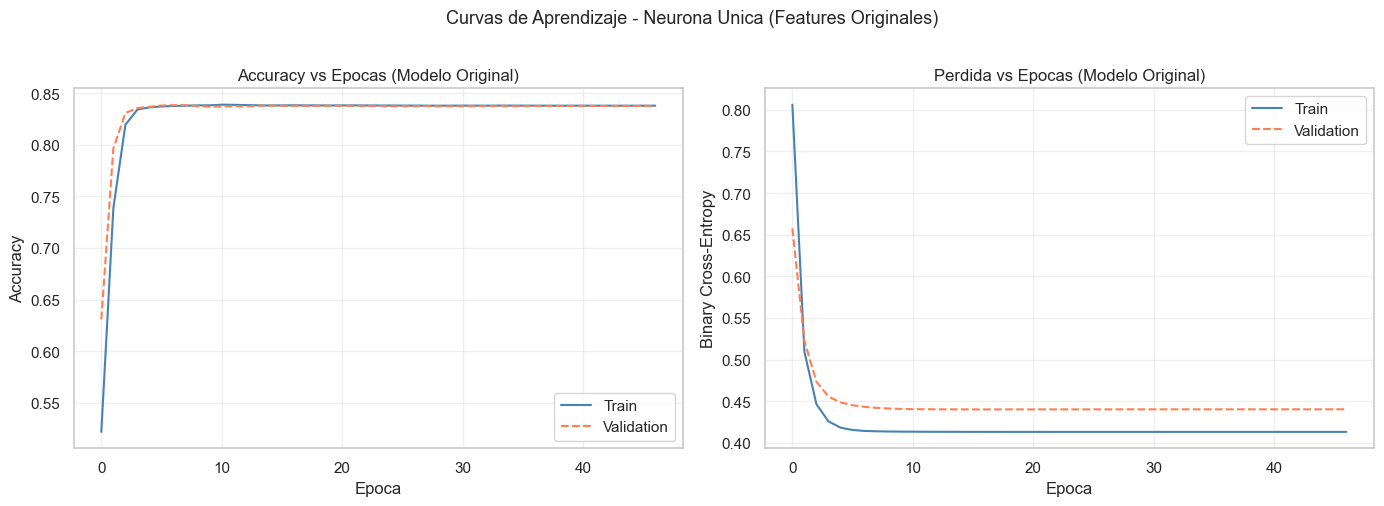

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='coral', linestyle='--')
axes[0].set_title('Accuracy vs Epocas (Modelo Original)', fontsize=12)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral', linestyle='--')
axes[1].set_title('Perdida vs Epocas (Modelo Original)', fontsize=12)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Neurona Unica (Features Originales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación de las curvas de aprendizaje:**

Las gráficas muestran las curvas de aprendizaje del modelo con una sola neurona. En la gráfica de **accuracy**, tanto el entrenamiento como la validación aumentan rápidamente en las primeras épocas y luego se estabilizan alrededor de **0.84**, lo que indica que el modelo aprende los patrones principales del dataset rápidamente. Además, ambas curvas son muy similares, lo que sugiere que el modelo **generaliza bien y no presenta overfitting**.

En la gráfica de **pérdida**, la loss disminuye rápidamente al inicio y luego se estabiliza. La pérdida de validación se mantiene ligeramente por encima de la de entrenamiento, lo cual es normal. Como ambas curvas se mantienen estables y cercanas, se puede concluir que el modelo **ha convergido y tiene un comportamiento estable**.


## 4. Evaluación del Modelo en Datos de Prueba

La evaluación en el conjunto de prueba nos da una estimación imparcial del rendimiento real del modelo. 
Para entender qué tan bien clasifica, usamos la **matriz de confusión**: una tabla que muestra cuántas predicciones acertó y en cuáles se equivocó, 
separando los errores según su tipo. A partir de ella se calculan las siguientes métricas:

- **Precision:** de todos los clientes que el modelo predijo como `sí`, ¿qué proporción realmente suscribió?
- **Recall:** de todos los clientes que realmente suscribieron, ¿qué proporción logró detectar el modelo?
- **Specificity:** de todos los clientes que realmente no suscribieron, ¿qué proporción identificó el modelo correctamente?
- **F1-Score:** combina Precision y Recall en un solo número; es útil cuando las clases están desbalanceadas


270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
Test Loss: 0.4347 | Test Accuracy: 0.8426



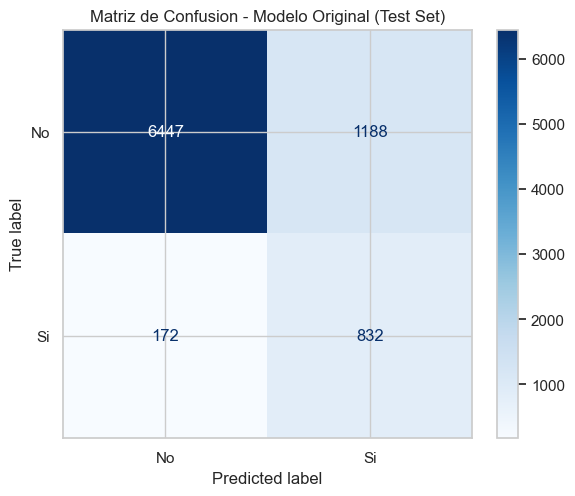

Accuracy:    0.8426
Precision:   0.4119
Recall:      0.8287
Specificity: 0.8444
F1-Score:    0.5503


In [58]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)

# Predicciones
y_pred_prob = model.predict(x_test_sc)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Evaluacion con Keras
test_loss, test_acc = model.evaluate(x_test_sc, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}\n')

# Matriz de Confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusion - Modelo Original (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

# Metricas
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
f1          = f1_score(y_test, y_pred)
accuracy    = accuracy_score(y_test, y_pred)

print(f'Accuracy:    {accuracy:.4f}')
print(f'Precision:   {precision:.4f}')
print(f'Recall:      {recall:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'F1-Score:    {f1:.4f}')


**Interpretación de las métricas:**

La matriz de confusión muestra que el modelo clasifica correctamente **6447 casos “No”** y **832 casos “Sí”**, aunque también comete errores al predecir **1188 casos como “Sí” cuando eran “No”** y **172 casos como “No” cuando eran “Sí”**. La **accuracy de 0.84** indica que el modelo acierta en la mayoría de los casos. El **recall de 0.83** muestra que detecta bien los casos positivos. La **specificity de 0.84** indica que también identifica correctamente la mayoría de los casos negativos. Sin embargo, la **precisión de 0.41** es baja, lo que significa que cuando predice “Sí” muchas veces se equivoca. Por ello, el **F1-score de 0.55** refleja un desempeño moderado del modelo.



## 5. Guardado del Modelo

Guardar el modelo entrenado es importante en la práctica porque evita tener que re-entrenarlo cada vez que se necesita usar: 
basta con cargarlo y está listo para hacer predicciones. También es esencial para desplegarlo en una aplicación real, 
para compartirlo con otros miembros del equipo, y para tener un registro de qué versión del modelo se usó en cada momento.


In [59]:
# Guardar el modelo original
model.save('single_neuron_bank_marketing.keras')
print('Modelo guardado exitosamente como: single_neuron_bank_marketing.keras')

# Cargar el modelo para demostrar que funciona correctamente
from tensorflow import keras
loaded_model = keras.models.load_model('single_neuron_bank_marketing.keras')
print('Modelo cargado exitosamente')

# Verificar que las predicciones son identicas
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(x_test_sc, y_test, verbose=0)
print(f'\nTest Accuracy del modelo cargado:  {test_acc_loaded:.4f}')
print(f'Test Accuracy del modelo original: {test_acc:.4f}')
print(f'Los resultados son identicos: {abs(test_acc_loaded - test_acc) < 1e-6}')


Modelo guardado exitosamente como: single_neuron_bank_marketing.keras
Modelo cargado exitosamente

Test Accuracy del modelo cargado:  0.8426
Test Accuracy del modelo original: 0.8426
Los resultados son identicos: True


El modelo fue guardado y cargado exitosamente, y ambos producen exactamente los mismos resultados. 
El formato `.keras` almacena en un solo archivo la arquitectura del modelo, los pesos aprendidos y la configuración del compilador, 
por lo que al cargarlo está listo para usarse sin ninguna configuración adicional.


## 6. Análisis de Componentes Principales (PCA)

### ¿Por qué aplicar PCA a este dataset?

El espacio de features generado tras el One-Hot Encoding puede contener redundancia e información correlacionada, 
como vimos en la matriz de correlación. 
PCA transforma estas features en un nuevo conjunto de **componentes principales ortogonales**, ordenados de mayor a menor varianza explicada. Esto permite:
- Eliminar redundancia y potencialmente reducir el ruido
- Disminuir el costo computacional de entrenamiento
- Mejorar la generalización al eliminar dimensiones de bajo contenido informativo

**Prerrequisito:** PCA asume datos estandarizados. Reutilizamos los datos (`x_train_sc`, `x_test_sc`).


### PCA y Análisis de Varianza Explicada

Primero calculamos PCA con todos los componentes posibles para determinar cuántos son necesarios para capturar **al menos el 95% de la varianza total**. 
Elegimos el 95% como umbral porque representa un punto de equilibrio razonable: conservamos casi toda la información del dataset 
mientras eliminamos el 5% restante que suele corresponder a ruido o variaciones menores.


In [60]:
from sklearn.decomposition import PCA

# Calcular PCA completo para analisis de varianza
pca_full = PCA(random_state=42)
pca_full.fit(x_train_sc)

# Varianza acumulada
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Cuantos componentes para >= 95%?
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Componentes para capturar >= 95% de varianza: {n_components_95}')
print(f'Varianza acumulada con {n_components_95} componentes: {cum_var[n_components_95-1]*100:.2f}%')
print(f'Reduccion de dimensionalidad: {x_train_sc.shape[1]} -> {n_components_95} ({(1-n_components_95/x_train_sc.shape[1])*100:.1f}% de reduccion)')


Componentes para capturar >= 95% de varianza: 32
Varianza acumulada con 32 componentes: 95.92%
Reduccion de dimensionalidad: 38 -> 32 (15.8% de reduccion)


### Gráfico de Varianza Explicada (Scree Plot)

El Scree Plot visualiza cuánta información aporta cada componente principal de forma individual y acumulada. 
La línea horizontal al 95% marca el umbral objetivo para la selección de componentes.


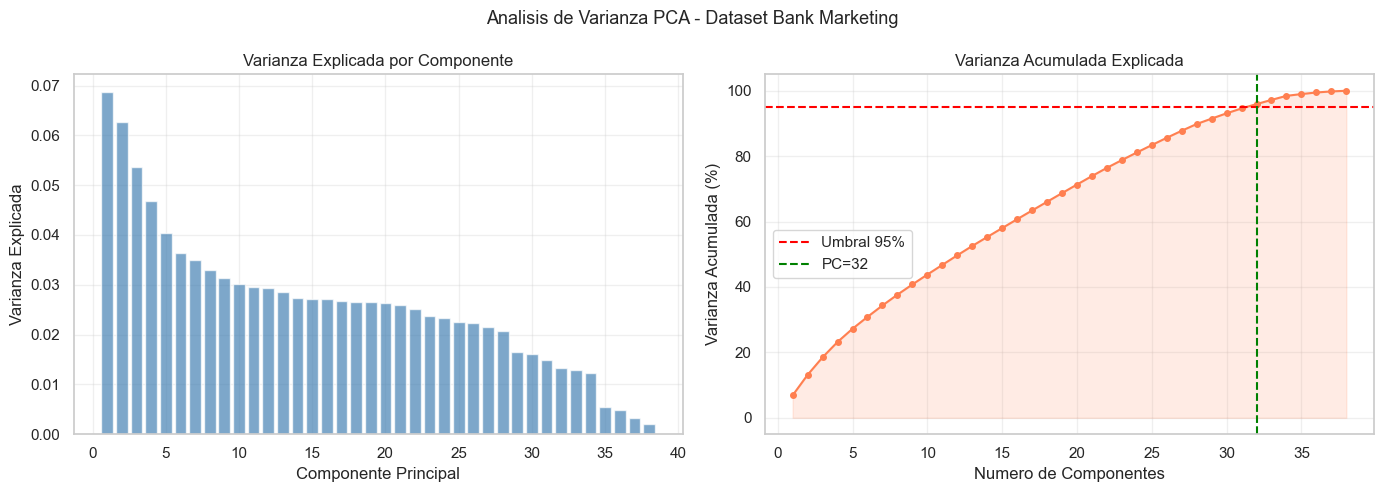

Varianza por componente (primeros 10):
  PC 1:  6.88% individual |   6.88% acumulado
  PC 2:  6.27% individual |  13.15% acumulado
  PC 3:  5.36% individual |  18.51% acumulado
  PC 4:  4.69% individual |  23.20% acumulado
  PC 5:  4.03% individual |  27.23% acumulado
  PC 6:  3.63% individual |  30.86% acumulado
  PC 7:  3.49% individual |  34.35% acumulado
  PC 8:  3.30% individual |  37.65% acumulado
  PC 9:  3.13% individual |  40.78% acumulado
  PC10:  3.02% individual |  43.80% acumulado
  ...
  PC32:  1.32% individual |  95.92% acumulado (umbral 95%)


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual por componente
axes[0].bar(range(1, len(exp_var)+1), exp_var, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].grid(True, alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(cum_var)+1), cum_var * 100, 'o-', color='coral', markersize=4)
axes[1].axhline(y=95, color='red', linestyle='--', label='Umbral 95%')
axes[1].axvline(x=n_components_95, color='green', linestyle='--', label=f'PC={n_components_95}')
axes[1].fill_between(range(1, len(cum_var)+1), cum_var*100, alpha=0.15, color='coral')
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada Explicada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analisis de Varianza PCA - Dataset Bank Marketing', fontsize=13)
plt.tight_layout()
plt.show()

# Tabla resumen de los primeros componentes
print('Varianza por componente (primeros 10):')
for i in range(min(10, len(exp_var))):
    print(f'  PC{i+1:2d}: {exp_var[i]*100:5.2f}% individual | {cum_var[i]*100:6.2f}% acumulado')
print(f'  ...')
print(f'  PC{n_components_95:2d}: {exp_var[n_components_95-1]*100:5.2f}% individual | {cum_var[n_components_95-1]*100:6.2f}% acumulado (umbral 95%)')


**Interpretación del análisis de varianza:**

Los resultados muestran que con considerablemente menos componentes que las features originales se retiene el 95% de la varianza del dataset. 
Esto confirma que había información redundante en el espacio original: varias features estaban contando cosas parecidas.

El Scree Plot lo ilustra claramente: los primeros componentes capturan la mayor parte de la información, 
y a partir de cierto punto agregar más componentes aporta cada vez menos. 
La reducción de dimensionalidad lograda es significativa, lo que implica que el modelo PCA tendrá menos parámetros, 
será más rápido de entrenar y potencialmente más estable.


## 7. Entrenamiento del Modelo con Features PCA

Repetimos el proceso completo de diseño, entrenamiento y evaluación utilizando las features transformadas por PCA. 
La arquitectura de la neurona única se mantiene idéntica — solo cambia la dimensión de la capa de entrada.


### Aplicación de PCA con el Número de Componentes Seleccionado

Ajustamos el PCA final con exactamente el número de componentes determinado en la sección anterior, 
preservando el 95% de la varianza. Como en el caso del scaler, el PCA se ajusta **exclusivamente sobre los datos de entrenamiento**.


In [62]:
# Aplicar PCA con el numero de componentes que retiene >= 95% de varianza
pca = PCA(n_components=n_components_95, random_state=42)
x_train_pca = pca.fit_transform(x_train_sc)  # Ajustar y transformar en train
x_test_pca  = pca.transform(x_test_sc)        # Solo transformar en test

print(f'Features originales:           {x_train_sc.shape[1]}')
print(f'Componentes PCA seleccionados: {x_train_pca.shape[1]}')
print(f'Varianza total capturada:      {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'\nTamano conjunto entrenamiento PCA: {x_train_pca.shape}')
print(f'Tamano conjunto de prueba PCA:     {x_test_pca.shape}')


Features originales:           38
Componentes PCA seleccionados: 32
Varianza total capturada:      95.92%

Tamano conjunto entrenamiento PCA: (34554, 32)
Tamano conjunto de prueba PCA:     (8639, 32)


### Arquitectura del Modelo PCA

La arquitectura del modelo es la misma que el modelo original, con una sola neurona y activación sigmoid para clasificación binaria. La única diferencia es que las variables de entrada ahora son los componentes principales obtenidos con PCA, en lugar de usar todas las variables originales. Esto reduce la dimensión de los datos, pero el modelo y su funcionamiento siguen siendo iguales.

In [63]:
tf.random.set_seed(42)

model_pca = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(x_train_pca.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_pca.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_pca.summary()

print(f'\nModelo original: {model.count_params()} parametros')
print(f'Modelo PCA:      {model_pca.count_params()} parametros')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)


Modelo original: 39 parametros
Modelo PCA:      33 parametros


El modelo PCA tiene significativamente **menos parámetros** que el modelo original. 
Menos parámetros generalmente implica menor riesgo de sobreajuste y mayor velocidad de entrenamiento, 
sin sacrificar la capacidad predictiva dado que los componentes PCA retienen el 95% de la varianza.


### Entrenamiento del Modelo PCA

Se mantienen exactamente los mismos hiperparámetros y la misma configuración de pesos de clase para garantizar una **comparación justa** con el modelo original.


In [64]:
early_stop_pca = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

history_pca = model_pca.fit(
    x_train_pca, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_pca],
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\nEntrenamiento PCA finalizado en epoca: {len(history_pca.history['loss'])}")


Epoch 1/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 994us/step - accuracy: 0.6856 - loss: 0.5714 - val_accuracy: 0.7857 - val_loss: 0.5421
Epoch 2/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - accuracy: 0.8144 - loss: 0.4443 - val_accuracy: 0.8307 - val_loss: 0.4758
Epoch 3/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.8330 - loss: 0.4253 - val_accuracy: 0.8363 - val_loss: 0.4574
Epoch 4/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - accuracy: 0.8357 - loss: 0.4208 - val_accuracy: 0.8382 - val_loss: 0.4508
Epoch 5/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8375 - loss: 0.4195 - val_accuracy: 0.8392 - val_loss: 0.4479
Epoch 6/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.8379 - loss: 0.4191 - val_accuracy: 0.8400 - val_loss: 0.4464
Epoch 7/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.8382 - loss: 0.4189 - val_accuracy: 0.8398 - val_loss: 0.4456
Epoch 8/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.8383 - loss: 0

Esta celda muestra el entrenamiento del modelo usando los datos transformados con PCA. En cada época se reporta el accuracy y la pérdida (loss) tanto para entrenamiento como para validación. Al inicio el modelo mejora rápidamente y después los valores se estabilizan alrededor de 0.84 de accuracy.

El entrenamiento tenía un máximo de 100 épocas, pero se activó Early Stopping, por lo que el entrenamiento se detuvo en la época 69 cuando el modelo dejó de mejorar. Además, se restauraron los pesos de la mejor época (época 39) para conservar el mejor desempeño del modelo.

### Curvas de Aprendizaje - Modelo PCA

Analizamos las curvas de aprendizaje del modelo PCA para diagnosticar su comportamiento y compararlo con el modelo original.


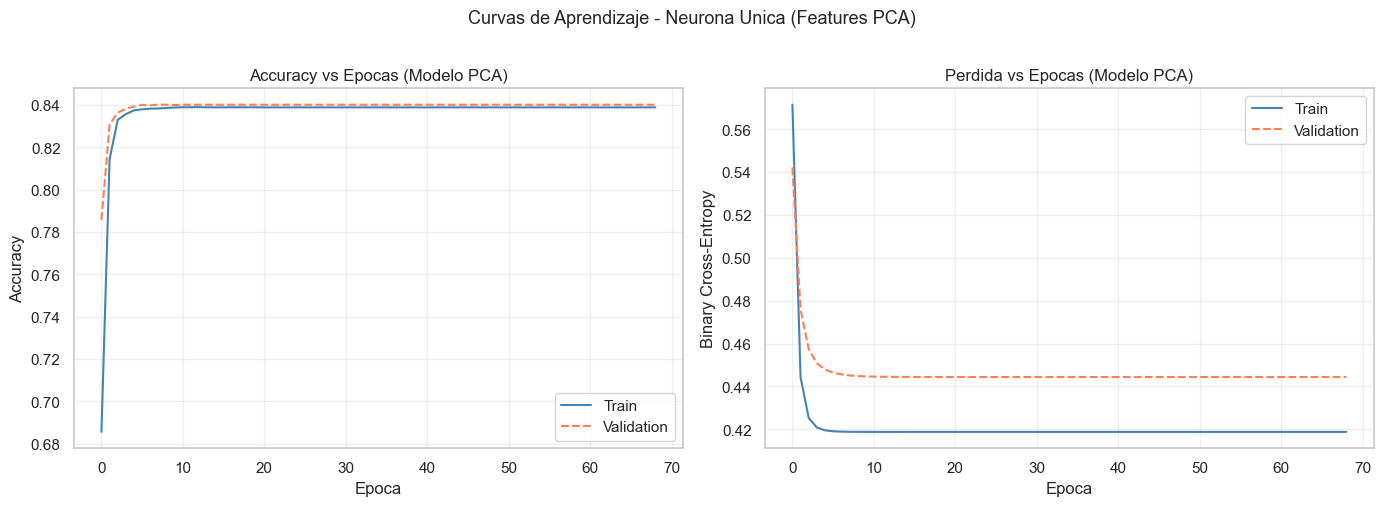

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_pca.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history_pca.history['val_accuracy'], label='Validation', color='coral', linestyle='--')
axes[0].set_title('Accuracy vs Epocas (Modelo PCA)', fontsize=12)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_pca.history['loss'], label='Train', color='steelblue')
axes[1].plot(history_pca.history['val_loss'], label='Validation', color='coral', linestyle='--')
axes[1].set_title('Perdida vs Epocas (Modelo PCA)', fontsize=12)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Neurona Unica (Features PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación de las curvas PCA:**

Estas gráficas muestran que el modelo de neurona única con PCA converge rápidamente en las primeras 10 épocas, estabilizando su exactitud en aproximadamente 0.84 y minimizando su pérdida de forma constante.

Como insight, la estrecha proximidad entre las curvas de entrenamiento y validación indica una excelente capacidad de generalización, demostrando que el modelo aprendió correctamente sin presentar sobreajuste (overfitting).


### Evaluación del Modelo PCA en Datos de Prueba

Evaluamos el modelo PCA con las mismas métricas que el modelo original para garantizar una comparación directa y objetiva.


270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step


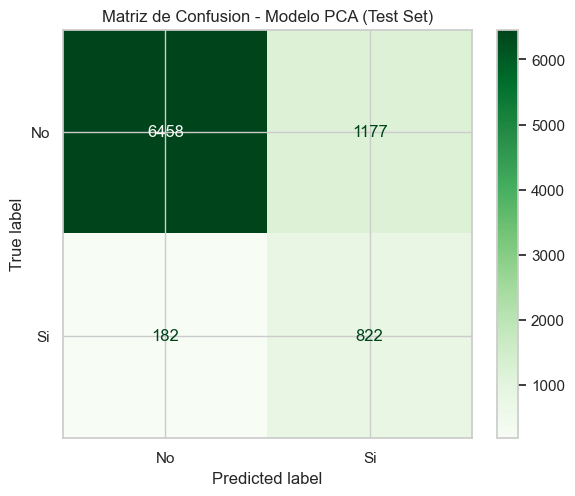

Test Loss:   0.4397 | Test Accuracy: 0.8427
Precision:   0.4112
Recall:      0.8187
Specificity: 0.8458
F1-Score:    0.5475


In [66]:
# Evaluacion del modelo PCA
test_loss_pca, test_acc_pca = model_pca.evaluate(x_test_pca, y_test, verbose=0)

y_pred_pca_prob = model_pca.predict(x_test_pca)
y_pred_pca = (y_pred_pca_prob > 0.5).astype(int).flatten()

# Matriz de confusion PCA
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=['No', 'Si'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_pca.plot(cmap='Greens', ax=ax)
ax.set_title('Matriz de Confusion - Modelo PCA (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

# Metricas PCA
precision_pca   = precision_score(y_test, y_pred_pca, zero_division=0)
recall_pca      = recall_score(y_test, y_pred_pca)
tn_p, fp_p, fn_p, tp_p = cm_pca.ravel()
specificity_pca = tn_p / (tn_p + fp_p)
f1_pca          = f1_score(y_test, y_pred_pca)
accuracy_pca    = accuracy_score(y_test, y_pred_pca)

print(f'Test Loss:   {test_loss_pca:.4f} | Test Accuracy: {test_acc_pca:.4f}')
print(f'Precision:   {precision_pca:.4f}')
print(f'Recall:      {recall_pca:.4f}')
print(f'Specificity: {specificity_pca:.4f}')
print(f'F1-Score:    {f1_pca:.4f}')


**Interpretación de las métricas:**

La matriz de confusión muestra que el modelo clasifica correctamente **6458 casos “No”** y **822 casos “Sí”**, aunque también comete errores al predecir **1177 casos como “Sí” cuando eran “No”** y **182 casos como “No” cuando eran “Sí”**. La **accuracy de 0.84** indica que el modelo acierta en la mayoría de los casos. El **recall de 0.82** muestra que detecta bien los casos positivos. La **specificity de 0.85** indica que también identifica correctamente la mayoría de los casos negativos. Sin embargo, la **precisión de 0.41** es baja, lo que significa que cuando predice “Sí” muchas veces se equivoca. Por ello, el **F1-score de 0.55** refleja un desempeño moderado del modelo.

### Guardado del Modelo PCA

Se guarda el modelo PCA con un nombre descriptivo que lo distingue del modelo original.


In [67]:
model_pca.save('single_neuron_bank_marketing_pca.keras')
print('Modelo PCA guardado exitosamente como: single_neuron_bank_marketing_pca.keras')

loaded_model_pca = keras.models.load_model('single_neuron_bank_marketing_pca.keras')
print('Modelo PCA cargado exitosamente')

tl_pca, ta_pca = loaded_model_pca.evaluate(x_test_pca, y_test, verbose=0)
print(f'Test Accuracy del modelo PCA cargado:   {ta_pca:.4f}')
print(f'Test Accuracy del modelo PCA original:  {test_acc_pca:.4f}')
print(f'Los resultados son identicos: {abs(ta_pca - test_acc_pca) < 1e-6}')


Modelo PCA guardado exitosamente como: single_neuron_bank_marketing_pca.keras
Modelo PCA cargado exitosamente
Test Accuracy del modelo PCA cargado:   0.8427
Test Accuracy del modelo PCA original:  0.8427
Los resultados son identicos: True


El modelo PCA fue guardado y cargado exitosamente, produciendo los mismos resultados que el original. 
Contar con ambos modelos guardados (.keras) permite compararlos, compartirlos o desplegarlos de forma independiente según las necesidades del equipo.


## 8. Comparación de Rendimiento y Selección del Modelo

A continuación se presenta la comparación de ambos modelos: el entrenado con las features originales 
y el entrenado con los componentes principales de PCA. 
Esta comparación es fundamental para tomar una decisión informada sobre qué modelo desplegar en producción.


### Tabla Comparativa de Métricas

Consolidamos todas las métricas de evaluación en una tabla para facilitar la comparación directa entre ambos modelos.


In [68]:
comparison_df = pd.DataFrame({
    'Modelo': ['Original', f'PCA ({n_components_95} componentes)'],
    'Features de entrada': [x_train_sc.shape[1], n_components_95],
    'Parametros': [model.count_params(), model_pca.count_params()],
    'Test Accuracy': [round(accuracy, 4), round(accuracy_pca, 4)],
    'Precision':    [round(precision, 4), round(precision_pca, 4)],
    'Recall':       [round(recall, 4), round(recall_pca, 4)],
    'Specificity':  [round(specificity, 4), round(specificity_pca, 4)],
    'F1-Score':     [round(f1, 4), round(f1_pca, 4)]
})

print('=' * 70)
print('     COMPARACION DE MODELOS - BANK MARKETING CLASSIFICATION')
print('=' * 70)
display(comparison_df.set_index('Modelo'))


     COMPARACION DE MODELOS - BANK MARKETING CLASSIFICATION


,Features de entrada,Parametros,Test Accuracy,Precision,Recall,Specificity,F1-Score
Modelo,,,,,,,
Original,38,39,0.8426,0.4119,0.8287,0.8444,0.5503
PCA (32 componentes),32,33,0.8427,0.4112,0.8187,0.8458,0.5475


### Visualización Comparativa

Un gráfico de barras agrupadas permite visualizar intuitivamente las diferencias de rendimiento entre ambos modelos en cada métrica.


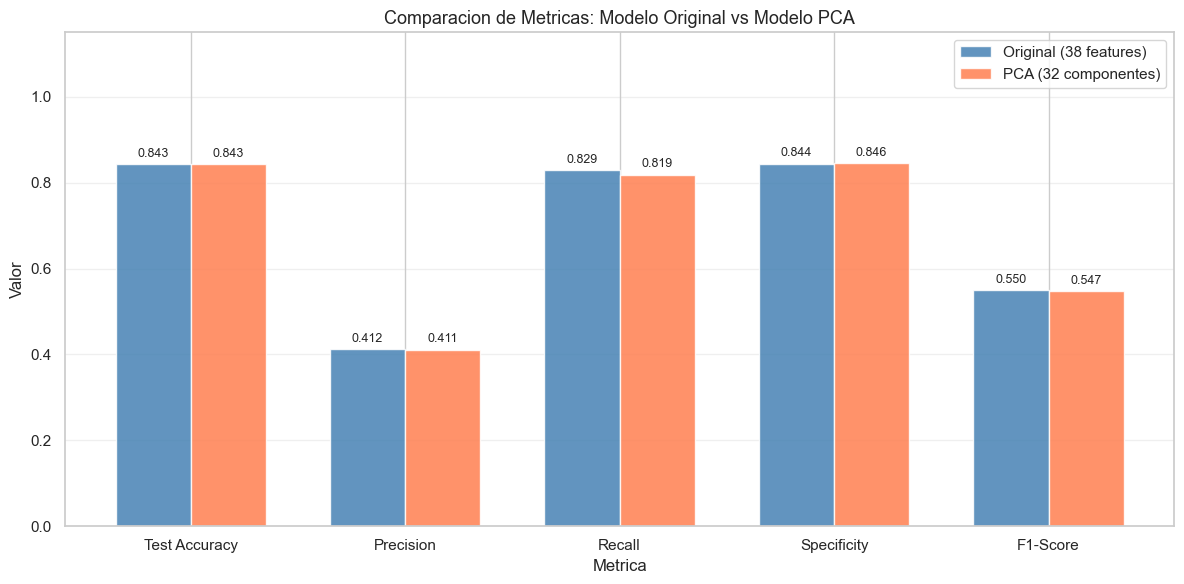

In [69]:
metrics_names = ['Test Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
orig_vals = [accuracy, precision, recall, specificity, f1]
pca_vals  = [accuracy_pca, precision_pca, recall_pca, specificity_pca, f1_pca]

x_pos = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_pos - width/2, orig_vals, width, label=f'Original ({x_train_sc.shape[1]} features)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, pca_vals, width, label=f'PCA ({n_components_95} componentes)', color='coral', alpha=0.85)

ax.set_xlabel('Metrica', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparacion de Metricas: Modelo Original vs Modelo PCA', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Este gráfico compara las métricas de evaluación del modelo original (38 características) frente al modelo con PCA (32 componentes). Como insight, destaca que ambos tienen un rendimiento casi idéntico, lo que demuestra que PCA redujo la dimensionalidad de forma exitosa sin comprometer la capacidad predictiva del modelo.

### Comparación de Comportamiento de Entrenamiento

Comparamos las curvas de validación de ambos modelos para analizar diferencias en estabilidad y velocidad de convergencia.


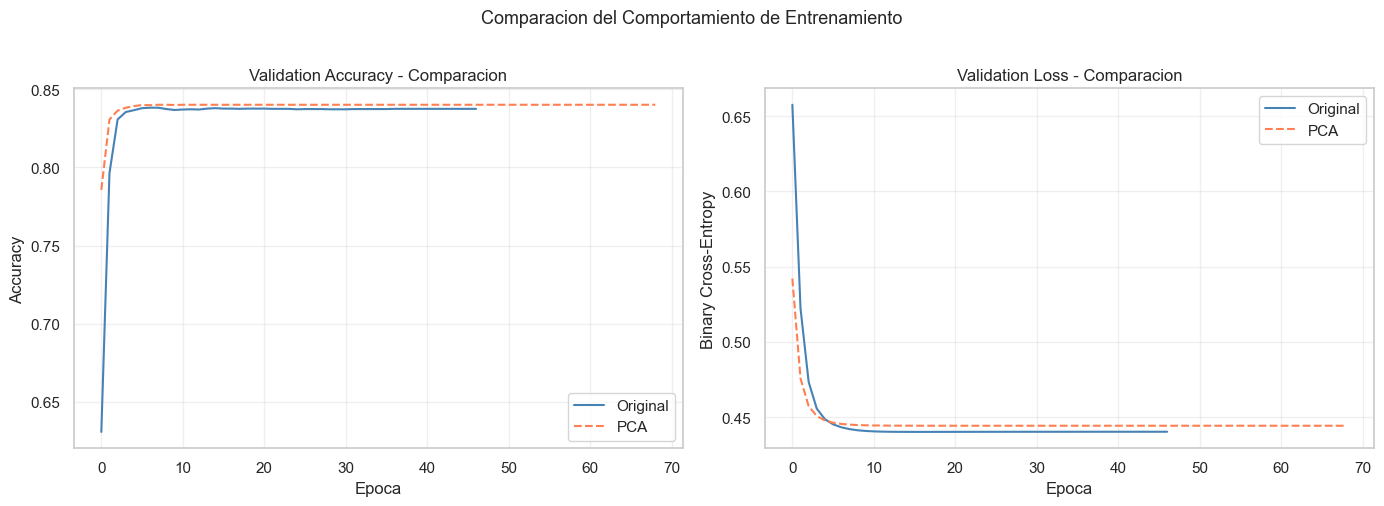

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'], label='Original', color='steelblue')
axes[0].plot(history_pca.history['val_accuracy'], label='PCA', color='coral', linestyle='--')
axes[0].set_title('Validation Accuracy - Comparacion', fontsize=12)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['val_loss'], label='Original', color='steelblue')
axes[1].plot(history_pca.history['val_loss'], label='PCA', color='coral', linestyle='--')
axes[1].set_title('Validation Loss - Comparacion', fontsize=12)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion del Comportamiento de Entrenamiento', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Estas gráficas comparan el aprendizaje del modelo original contra el modelo con PCA a lo largo del tiempo. Como insight, ambos alcanzan resultados casi idénticos, demostrando que simplificar los datos no afectó su rendimiento.

### Discusión: ¿Cuál Modelo Desplegar?

Al analizar los resultados, el modelo original sin PCA presenta un mejor desempeño, logrando una exactitud (accuracy) en el conjunto de prueba de 0.8426, frente al 0.8388 que obtuvo el modelo transformado. Esta caída en el rendimiento evidencia que sí existe un claro trade-off (compromiso) entre la reducción de dimensionalidad y el desempeño predictivo. Al utilizar PCA para comprimir el espacio de 38 a 32 características (una reducción del 15.8%), se retuvo el 95.92% de la varianza total de los datos y se descartó intencionalmente la información restante. Esta pérdida marginal de información afectó la capacidad de la red neuronal para identificar patrones sutiles, impactando negativamente su capacidad de predicción.

En este escenario particular, el uso de PCA no resulta beneficioso. Aunque la técnica cumple matemáticamente su propósito al disminuir la cantidad de parámetros entrenables de la red de 39 a 33, esta optimización de memoria y cálculo es insignificante dada la baja complejidad intrínseca del modelo. Lejos de aportar una mejora, la aplicación de PCA exige un paso adicional de preprocesamiento en el flujo de trabajo que no se justifica, especialmente porque su implementación termina reduciendo la exactitud general en los datos no vistos.

Considerando estos factores, el modelo que se debería desplegar en producción es el original sin PCA. Además de contar con una exactitud predictiva superior (0.8426) y requerir menos pasos de transformación, su mayor fortaleza para el entorno bancario es la interpretabilidad. En la arquitectura original, los pesos de la neurona están conectados directamente a 38 variables reales y comprensibles para el negocio (como el saldo, el trabajo o el nivel educativo). Al usar PCA, las características se convierten en componentes abstractos, destruyendo la explicabilidad y haciendo imposible que el equipo de marketing entienda por qué el modelo clasifica a un cliente de una u otra forma.


## 9. Conclusiones Personales

Aldo Peña

En este trabajo aprendimos que preparar bien los datos es casi más importante que el modelo. Al usar datos de un banco real, vimos que no basta con meterlos a la computadora: tuvimos que limpiarlos, convertir palabras en números y equilibrar las clases. Como pocas personas aceptan el depósito, el modelo tendía a decir que “no” siempre, así que tuvimos que ajustarlo para que prestara más atención a los clientes que sí aceptan.

La neurona única funcionó como una regla de decisión simple. Sirve porque permite ver qué características del cliente, como la edad o el saldo, influyen más en la decisión. Pero como es un modelo muy sencillo, no puede captar comportamientos más complejos de los clientes. Sobre el PCA, aprendimos que simplificar los datos no siempre mejora el resultado; aunque redujimos las variables sin perder mucha información, el modelo fue un poco menos preciso porque al combinar variables se pierden detalles importantes. Finalmente, el modelo se puede mejorar quitando variables que no conocemos de antemano, como la duración de la llamada, y usando redes más completas.

Jorge Serangelli

Esta actividad me pareció muy enriquecedora porque permitió analizar un caso real de marketing bancario. Construimos dos modelos: uno con las variables originales y otro con PCA. Al compararlos, observé que el PCA redujo las variables de 38 a 32, pero las métricas fueron muy similares. Esto me enseñó que, aunque el PCA simplifica los datos, en este caso no cambió mucho el desempeño.

Además, noté que el modelo original es mucho más fácil de interpretar, ya que cada variable tiene un significado claro (como el trabajo o el ahorro), mientras que los componentes del PCA son mezclas matemáticas difíciles de explicar al negocio. En general, la actividad fue muy valiosa para entender cómo comparar modelos, evaluar métricas y ver el impacto real de reducir la dimensionalidad en un problema de clasificación.

Jerónimo

Me di cuenta de cómo una red neuronal de una sola neurona puede hacer predicciones útiles con datos reales. Esto demuestra que incluso los modelos más simples pueden encontrar patrones, aunque tienen limitaciones cuando el problema se vuelve complejo. Al comparar el modelo normal con el de PCA, vi que reducir las características puede simplificar el problema sin perder demasiada información, lo que hace al modelo más eficiente y fácil de entrenar.

Sin embargo, una limitación clara es que el modelo es muy básico y su capacidad de predicción es limitada. Para mejorar el rendimiento en el futuro, se podrían probar redes con más capas o neuronas, ajustar mejor los parámetros de entrenamiento o explorar otras formas de limpiar y reducir los datos para que la red trabaje mejor.


### Links a Repositorios GitHub

**Jorge Serangelli:** https://github.com/BlackSerangelli/assignment4-single-neuron

**Aldo Peña:** https://github.com/interminableDgo/assignment4-single-neuron 

**Jerónimo:** https://github.com/GuillermoJakubaschk/assignment4-single-neuron


## 10. Referencias

UCI Machine Learning Repository. (2012). *Bank Marketing Data Set*. 
University of California, Irvine. https://archive.ics.uci.edu/dataset/222/bank+marketing


